In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import os

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [2]:
# 1. LOAD & SORT DATA

df = pd.read_csv('../Data/gold_baru.csv')
df['date'] = pd.to_datetime(df['date'])
df.sort_values('date', ascending=True, inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"Data: {df.shape}  |  {df['date'].iloc[0].date()} → {df['date'].iloc[-1].date()}")

Data: (521, 9)  |  2015-01-01 → 2024-12-19


In [3]:
df

,date,open,high,low,close,ffr,nfp,y,arah
0,2015-01-01,1184.000000,1220.000000,1169.500000,1210.599976,0.25,259,1234.400024,Naik
1,2015-01-08,1207.000000,1243.800049,1206.300049,1234.400024,0.25,259,1293.699951,Naik
2,2015-01-15,1231.500000,1303.500000,1227.300049,1293.699951,0.25,259,1285.900024,Turun
3,2015-01-22,1293.199951,1302.099976,1277.199951,1285.900024,0.25,259,1263.800049,Turun
4,2015-01-29,1283.300049,1285.400024,1251.000000,1263.800049,0.25,259,1219.000000,Turun
...,...,...,...,...,...,...,...,...,...
516,2024-11-21,2659.300049,2710.500000,2616.800049,2639.899902,4.75,33,2653.800049,Naik
517,2024-11-28,2636.399902,2664.300049,2620.699951,2653.800049,4.75,33,2733.800049,Naik
518,2024-12-05,2652.399902,2733.800049,2617.500000,2733.800049,4.75,33,2636.500000,Turun
519,2024-12-12,2725.100098,2725.100098,2590.199951,2636.500000,4.75,134,2620.000000,Turun


In [4]:
jumlah_arah = df['arah'].value_counts()

print("Jumlah Naik :", jumlah_arah.get('Naik', 0))
print("Jumlah Turun:", jumlah_arah.get('Turun', 0))

Jumlah Naik : 279
Jumlah Turun: 242


In [5]:
# 2. FEATURE ENGINEERING — RASIO (SCALE-INVARIANT)

# Semua fitur price dibagi close minggu sebelumnya
# Sehingga nilainya selalu sekitar 1.0, tidak peduli harga absolut
df['close_lag1']  = df['close'].shift(1)
df['close_lag2']  = df['close'].shift(2)

# Fitur utama (open, high, low → pakai dari feature_cols asal)
df['open_ratio']  = df['open']  / df['close_lag1']   # ~1.0
df['high_ratio']  = df['high']  / df['close_lag1']   # ≥1.0
df['low_ratio']   = df['low']   / df['close_lag1']   # ≤1.0
df['range_ratio'] = (df['high'] - df['low']) / df['close_lag1']  # volatilitas

# FFR & NFP (langsung, sudah stable rangenya)
df['ffr_chg']     = df['ffr'].diff().fillna(0)       # perubahan suku bunga

# KUNCI: return minggu ini & lalu (lag-1 corr=0.46 dengan target)
df['ret_this']    = df['close'] / df['close_lag1']   # return minggu ini
df['ret_lag2']    = df['close_lag1'] / df['close_lag2']  # return 2 minggu lalu


# Saat deploy: kalikan pred_ratio × close_terkini → harga prediksi
df['y_ratio']     = df['y'] / df['close_lag1']

df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

feature_cols = [
    'open_ratio', 'high_ratio', 'low_ratio', 'range_ratio',
    'ffr', 'ffr_chg','nfp',
    'ret_this', 'ret_lag2'
]
target_col = 'y_ratio'

print(f"\nFeatures: {feature_cols}")
print(f"Target  : {target_col}  (y / close_lag1)")


Features: ['open_ratio', 'high_ratio', 'low_ratio', 'range_ratio', 'ffr', 'ffr_chg', 'nfp', 'ret_this', 'ret_lag2']
Target  : y_ratio  (y / close_lag1)


In [6]:
# Cek fitur yang akan masuk ke model
df[feature_cols]

,open_ratio,high_ratio,low_ratio,range_ratio,ffr,ffr_chg,nfp,ret_this,ret_lag2
0,0.997651,1.055979,0.994248,0.061730,0.25,0.00,259,1.048039,1.019660
1,0.999614,1.006493,0.987246,0.019247,0.25,0.00,259,0.993971,1.048039
2,0.997978,0.999611,0.972859,0.026752,0.25,0.00,259,0.982814,0.993971
3,1.006330,1.006963,0.964551,0.042412,0.25,0.00,259,0.964551,0.982814
4,0.999098,1.012305,0.982609,0.029696,0.25,0.00,259,0.984167,0.964551
...,...,...,...,...,...,...,...,...,...
514,1.004192,1.023525,0.988143,0.035383,4.75,0.00,33,0.996866,1.026116
515,0.998674,1.009243,0.992727,0.016516,4.75,0.00,33,1.005265,0.996866
516,0.999472,1.030145,0.986321,0.043824,4.75,0.00,33,1.030145,1.005265
517,0.996818,0.996818,0.947472,0.049345,4.75,0.00,134,0.964408,1.030145


In [7]:
df[target_col].head()

0    1.041721
1    0.976888
2    0.947974
3    0.949280
4    0.985234
Name: y_ratio, dtype: float64

In [8]:
# 3. SPLIT + SCALE

X_raw = df[feature_cols].values
y_raw = df[target_col].values.reshape(-1, 1)

split = int(len(X_raw) * 0.7)
X_train_u = X_raw[:split];  y_train_u = y_raw[:split]
X_test_u  = X_raw[split:];  y_test_u  = y_raw[split:]
print(f"\nTrain: {len(X_train_u)} | Test: {len(X_test_u)}")

# StandardScaler → tidak ada batas [0,1], lebih toleran terhadap input baru
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_s = scaler_X.fit_transform(X_train_u)
y_train_s = scaler_y.fit_transform(y_train_u)
X_test_s  = scaler_X.transform(X_test_u)
y_test_s  = scaler_y.transform(y_test_u)


Train: 363 | Test: 156


In [9]:
# ─── CONTOH HASIL STANDARISASI ───────────────────────────────────────────────
# Pilih tanggal yang ingin ditampilkan sebagai contoh (sesuai gambar)
target_date = '2015-01-15'

# Cari baris yang sesuai; jika tidak ada, ambil baris pertama data test
date_mask = df['date'] == pd.Timestamp(target_date)
if date_mask.any():
    sample_idx = df[date_mask].index[0]
else:
    sample_idx = split                           # fallback: baris pertama test
    target_date = str(df['date'].iloc[sample_idx].date())

sample_date = df['date'].iloc[sample_idx].strftime('%Y-%m-%d')

# Ambil nilai mentah (X) dari baris yang dipilih
X_sample = X_raw[sample_idx]

# Mean (μ) dan Std Dev (σ) dari scaler yang sudah di-fit pada training data
means = scaler_X.mean_        # shape: (n_features,)
stds  = scaler_X.scale_       # shape: (n_features,)

# Hitung Z-score  Z = (X - μ) / σ
z_scores = (X_sample - means) / stds

# Bangun tabel
rows = []
for i, feat in enumerate(feature_cols):
    z = round(float(z_scores[i]), 3)
    rows.append({
        'Fitur'         : feat,
        'X (Nilai)'     : round(float(X_sample[i]), 5),
        'μ (Mean)'      : round(float(means[i]),    5),
        'σ (Std Dev)'   : round(float(stds[i]),     5),
        'Z = (X−μ)/σ'  : z,
        'Keterangan'    : 'Normal'
    })

df_standarisasi = pd.DataFrame(rows)

print(f"Tabel Contoh Hasil Standarisasi (Minggu {sample_date})")
print("=" * 70)
print(df_standarisasi.to_string(index=False))

# ─── Simpan ke CSV ────────────────────────────────────────────────────────────


Tabel Contoh Hasil Standarisasi (Minggu 2015-01-15)
      Fitur  X (Nilai)  μ (Mean)  σ (Std Dev)  Z = (X−μ)/σ Keterangan
 open_ratio    0.99765   1.00032      0.00545       -0.490     Normal
 high_ratio    1.05598   1.01437      0.01577        2.638     Normal
  low_ratio    0.99425   0.98786      0.01400        0.456     Normal
range_ratio    0.06173   0.02651      0.01552        2.270     Normal
        ffr    0.25000   0.98416      0.80946       -0.907     Normal
    ffr_chg    0.00000   0.00000      0.07423        0.000     Normal
        nfp  259.00000  74.48760   2513.42224        0.073     Normal
   ret_this    1.04804   1.00125      0.02003        2.336     Normal
   ret_lag2    1.01966   1.00130      0.02006        0.916     Normal


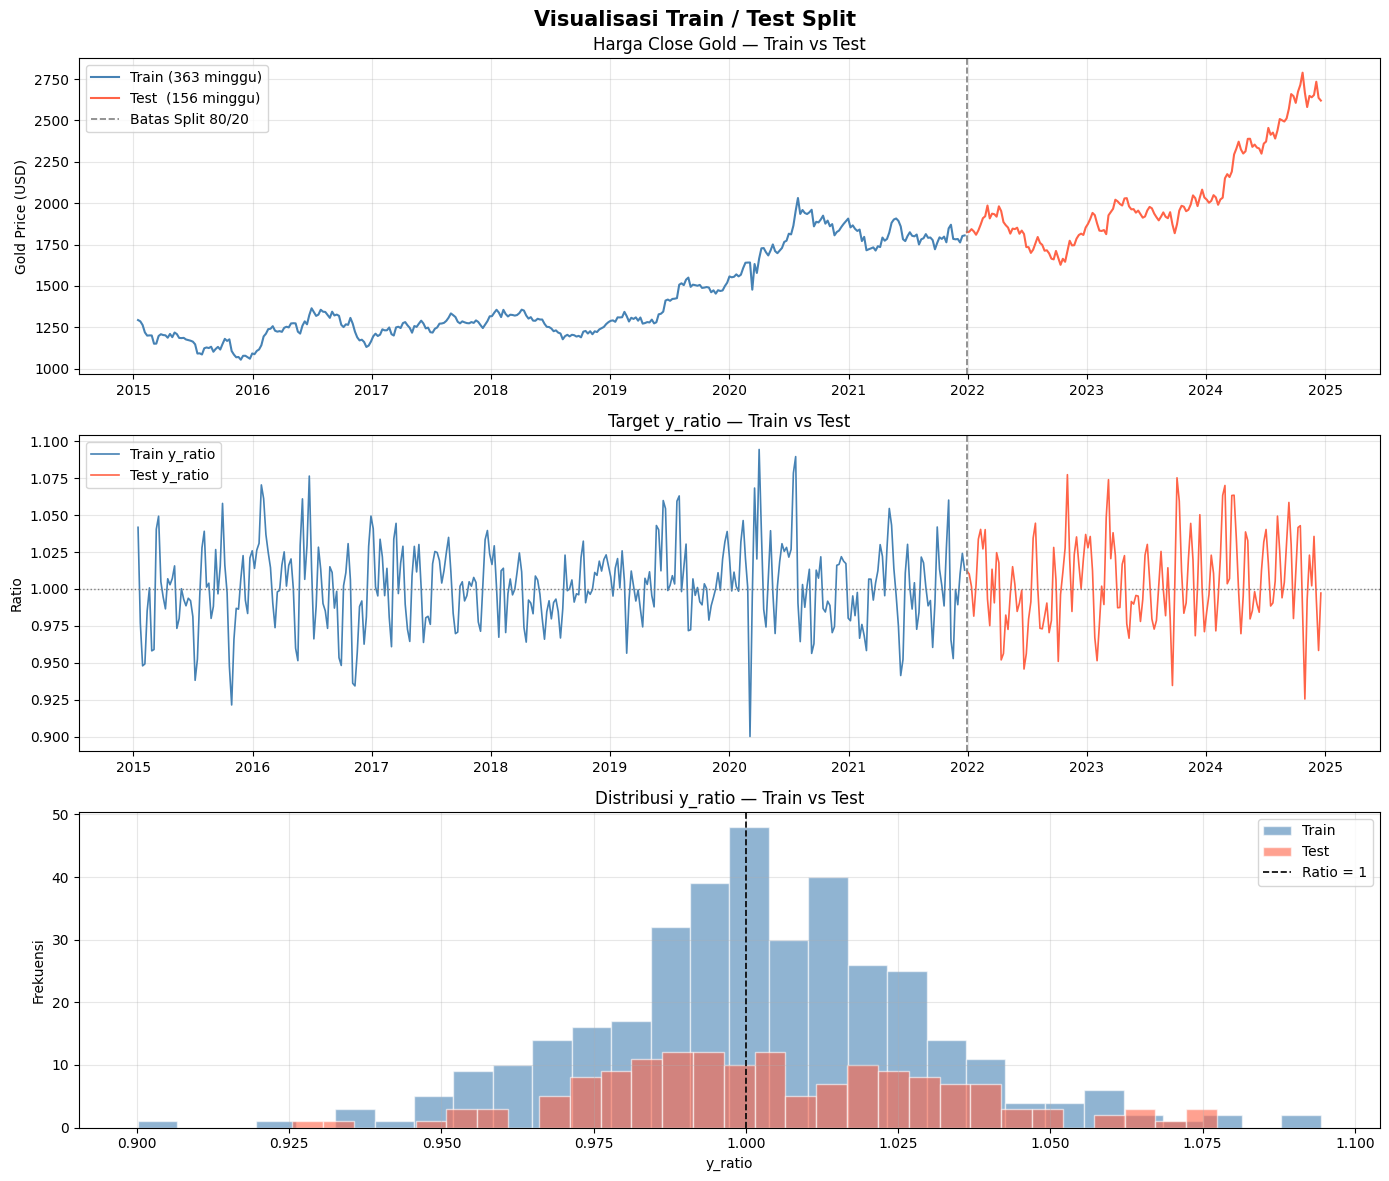

Train : 2015-01-15 → 2021-12-23  (363 baris)
Test  : 2021-12-30  → 2024-12-19   (156 baris)
Train close — mean: 1414.87  std: 256.42
Test  close — mean: 2042.33  std: 288.13


In [10]:
# 3b. VISUALISASI TRAIN / TEST SPLIT

train_dates = df['date'].iloc[:split]
test_dates  = df['date'].iloc[split:]
train_close = df['close'].iloc[:split]
test_close  = df['close'].iloc[split:]

fig, axes = plt.subplots(3, 1, figsize=(14, 12))
fig.suptitle('Visualisasi Train / Test Split', fontsize=15, fontweight='bold')

# Plot 1: Close Price dengan shading
ax = axes[0]
ax.plot(train_dates, train_close, color='steelblue', linewidth=1.5, label=f'Train ({len(train_close)} minggu)')
ax.plot(test_dates,  test_close,  color='tomato',    linewidth=1.5, label=f'Test  ({len(test_close)} minggu)')
ax.axvline(x=df['date'].iloc[split], color='gray', linestyle='--', linewidth=1.2, label='Batas Split 80/20')
ax.set_title('Harga Close Gold — Train vs Test')
ax.set_ylabel('Gold Price (USD)')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)

# Plot 2: y_ratio (target) train vs test
ax2 = axes[1]
ax2.plot(train_dates, df['y_ratio'].iloc[:split], color='steelblue', linewidth=1.2, label='Train y_ratio')
ax2.plot(test_dates,  df['y_ratio'].iloc[split:], color='tomato',    linewidth=1.2, label='Test y_ratio')
ax2.axhline(y=1.0, color='gray', linestyle=':', linewidth=1)
ax2.axvline(x=df['date'].iloc[split], color='gray', linestyle='--', linewidth=1.2)
ax2.set_title('Target y_ratio — Train vs Test')
ax2.set_ylabel('Ratio')
ax2.legend(loc='upper left')
ax2.grid(alpha=0.3)

# Plot 3: Distribusi y_ratio (histogram)
ax3 = axes[2]
ax3.hist(df['y_ratio'].iloc[:split], bins=30, color='steelblue', alpha=0.6, label='Train', edgecolor='white')
ax3.hist(df['y_ratio'].iloc[split:], bins=30, color='tomato',    alpha=0.6, label='Test',  edgecolor='white')
ax3.axvline(x=1.0, color='black', linestyle='--', linewidth=1.2, label='Ratio = 1')
ax3.set_title('Distribusi y_ratio — Train vs Test')
ax3.set_xlabel('y_ratio')
ax3.set_ylabel('Frekuensi')
ax3.legend()
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print('=' * 50)
print(f"Train : {train_dates.iloc[0].date()} → {train_dates.iloc[-1].date()}  ({len(train_close)} baris)")
print(f"Test  : {test_dates.iloc[0].date()}  → {test_dates.iloc[-1].date()}   ({len(test_close)} baris)")
print('=' * 50)
print(f"Train close — mean: {train_close.mean():.2f}  std: {train_close.std():.2f}")
print(f"Test  close — mean: {test_close.mean():.2f}  std: {test_close.std():.2f}")


In [11]:
# 4. BUAT SEQUENCE
WINDOW_SIZE = 4   # 4 minggu (sinyal momentum pendek paling relevan)

def create_sequences(X, y, ws):
    Xs, ys = [], []
    for i in range(ws, len(X) + 1):
        Xs.append(X[i-ws:i])
        ys.append(y[i-1])
    return np.array(Xs), np.array(ys)

X_train, y_train = create_sequences(X_train_s, y_train_s, WINDOW_SIZE)
X_test,  y_test  = create_sequences(X_test_s,  y_test_s,  WINDOW_SIZE)
print(f"\nX_train: {X_train.shape}  |  X_test: {X_test.shape}")



X_train: (360, 4, 9)  |  X_test: (153, 4, 9)


In [12]:
# 5. BUILD & TRAIN MODEL

SEED = 123
np.random.seed(SEED)
tf.random.set_seed(SEED)

model = Sequential([
    LSTM(24, return_sequences=True, input_shape=(WINDOW_SIZE, len(feature_cols))),
    Dropout(0.3),
    LSTM(12),
    Dropout(0.3),
    Dense(1)
])
model.compile(optimizer=tf.keras.optimizers.Adam(0.001), loss='mse')
model.summary()

callbacks = [
    ReduceLROnPlateau(patience=5, factor=0.5, verbose=1)
]

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
)



Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 4, 24)             3264      
                                                                 
 dropout (Dropout)           (None, 4, 24)             0         
                                                                 
 lstm_1 (LSTM)               (None, 12)                1776      
                                                                 
 dropout_1 (Dropout)         (None, 12)                0         
                                                                 
 dense (Dense)               (None, 1)                 13        
                                                                 
Total params: 5053 (19.74 KB)
Trainable params: 5053 (19.74 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Epoch 1/50

21/21 [==

In [13]:
# 6. EVALUASI

y_pred_s    = model.predict(X_test)
pred_ratio  = scaler_y.inverse_transform(y_pred_s).flatten()
true_ratio  = scaler_y.inverse_transform(y_test).flatten()

# Index awal data test pada dataframe asli
test_start_idx = split + WINDOW_SIZE - 1

# Ambil close acuan sesuai baris test
close_lag1_test = df['close_lag1'].iloc[
    test_start_idx:test_start_idx + len(pred_ratio)
].values

close_this_test = df['close'].iloc[
    test_start_idx:test_start_idx + len(pred_ratio)
].values

# Konversi rasio ke harga absolut
# Karena target: y_ratio = y / close_lag1
y_pred_price = close_lag1_test * pred_ratio
y_true_price = close_lag1_test * true_ratio

# RMSE harga absolut
rmse = np.sqrt(mean_squared_error(y_true_price, y_pred_price))

# ======================================================
# DSTAT 1 — SESUAI TARGET MODEL
# Arah terhadap close_lag1
# ======================================================
actual_up_lag1 = true_ratio > 1.0
pred_up_lag1   = pred_ratio > 1.0
dstat_lag1     = np.mean(actual_up_lag1 == pred_up_lag1) * 100
baseline_lag1  = np.mean(actual_up_lag1) * 100

# ======================================================
# DSTAT 2 — ARAH MINGGU DEPAN DARI CLOSE MINGGU INI
# Arah terhadap close this week
# ======================================================
actual_up_this = y_true_price > close_this_test
pred_up_this   = y_pred_price > close_this_test
dstat_this     = np.mean(actual_up_this == pred_up_this) * 100
baseline_this  = np.mean(actual_up_this) * 100

print(f"RMSE                         : ${rmse:.2f}")

print("\n=== DSTAT TERHADAP CLOSE_LAG1 / TARGET MODEL ===")
print(f"D-Stat Close Lag1             : {dstat_lag1:.2f}%")
print(f"Baseline Close Lag1 (↑)       : {baseline_lag1:.2f}%")
print(f"Beat Baseline Close Lag1      : {'YES ✓' if dstat_lag1 > baseline_lag1 else 'NO ✗'}")

print("\n=== DSTAT TERHADAP CLOSE MINGGU INI ===")
print(f"D-Stat Close This Week        : {dstat_this:.2f}%")
print(f"Baseline Close This Week (↑)  : {baseline_this:.2f}%")
print(f"Beat Baseline Close This Week : {'YES ✓' if dstat_this > baseline_this else 'NO ✗'}")

5/5 [==============================] - 1s 3ms/step
RMSE                         : $48.30

=== DSTAT TERHADAP CLOSE_LAG1 / TARGET MODEL ===
D-Stat Close Lag1             : 72.55%
Baseline Close Lag1 (↑)       : 52.29%
Beat Baseline Close Lag1      : YES ✓

=== DSTAT TERHADAP CLOSE MINGGU INI ===
D-Stat Close This Week        : 49.02%
Baseline Close This Week (↑)  : 51.63%
Beat Baseline Close This Week : NO ✗


In [14]:
diagnostic = pd.DataFrame({
    'date': df['date'].iloc[test_start_idx:test_start_idx + len(pred_ratio)].values,
    'close_lag1': close_lag1_test,
    'close_this_week': close_this_test,
    'pred_close': y_pred_price,
    'actual_next_close': y_true_price,

    # Arah prediksi berdasarkan close_lag1
    'pred_vs_lag1': np.where(pred_ratio > 1.0, 'Naik', 'Turun'),

    # Arah aktual berdasarkan close_lag1
    'actual_vs_lag1': np.where(true_ratio > 1.0, 'Naik', 'Turun'),

    # Arah aktual sebenarnya dari close minggu ini ke minggu depan
    'actual_vs_this_week': np.where(y_true_price > close_this_test, 'Naik', 'Turun'),

    # Status DStat lama
    'status_lag1': np.where((pred_ratio > 1.0) == (true_ratio > 1.0), 'Benar', 'Salah'),

    # Yang kamu tanyakan:
    # Apakah sinyal model berdasarkan lag1 cocok dengan arah aktual dari close minggu ini?
    'status_signal_to_this_week': np.where((pred_ratio > 1.0) == (y_true_price > close_this_test), 'Benar', 'Salah'),
})

diagnostic.tail(20)

,date,close_lag1,close_this_week,pred_close,actual_next_close,pred_vs_lag1,actual_vs_lag1,actual_vs_this_week,status_lag1,status_signal_to_this_week
133,2024-08-08,2390.500000,2439.399902,2458.939489,2508.399902,Naik,Naik,Naik,Benar,Benar
134,2024-08-15,2439.399902,2508.399902,2524.041351,2501.000000,Naik,Naik,Turun,Benar,Salah
135,2024-08-22,2508.399902,2501.000000,2535.475381,2493.399902,Naik,Turun,Turun,Salah,Salah
136,2024-08-29,2501.000000,2493.399902,2532.409305,2512.100098,Naik,Naik,Naik,Benar,Benar
137,2024-09-05,2493.399902,2512.100098,2532.948993,2570.699951,Naik,Naik,Naik,Benar,Benar
138,2024-09-12,2512.100098,2570.699951,2573.703181,2659.199951,Naik,Naik,Naik,Benar,Benar
139,2024-09-19,2570.699951,2659.199951,2620.299403,2647.100098,Naik,Naik,Turun,Benar,Salah
140,2024-09-26,2659.199951,2647.100098,2673.821004,2606.000000,Naik,Turun,Turun,Salah,Salah
141,2024-10-03,2647.100098,2606.000000,2657.866968,2674.000000,Naik,Naik,Naik,Benar,Benar
142,2024-10-10,2606.000000,2674.000000,2674.480207,2714.399902,Naik,Naik,Naik,Benar,Benar


In [22]:
akurasi_signal_to_this = (
    diagnostic['status_signal_to_this_week'].eq('Benar').mean() * 100
)

print(f"Akurasi sinyal lag1 terhadap arah aktual close_this → next: {akurasi_signal_to_this:.2f}%")

Akurasi sinyal lag1 terhadap arah aktual close_this → next: 51.63%


In [ ]:
# # 6. EVALUASI

# y_pred_s    = model.predict(X_test)
# pred_ratio  = scaler_y.inverse_transform(y_pred_s).flatten()
# true_ratio  = scaler_y.inverse_transform(y_test).flatten()

# # Konversi ke harga absolut untuk RMSE
# test_start_idx = split + WINDOW_SIZE - 1
# test_close     = df['close_lag1'].iloc[test_start_idx:test_start_idx + len(pred_ratio)].values
# y_pred_price   = test_close * pred_ratio
# y_true_price   = test_close * true_ratio

# rmse = np.sqrt(mean_squared_error(y_true_price, y_pred_price))

# # D-Stat: arah naik/turun dari close minggu ini
# actual_up = true_ratio > 1.0
# pred_up   = pred_ratio > 1.0
# dstat     = np.mean(actual_up == pred_up) * 100
# baseline  = np.mean(actual_up) * 100   # always-up baseline


# print(f"RMSE          : ${rmse:.2f}")
# print(f"D-Stat        : {dstat:.2f}%")
# print(f"Baseline (↑)  : {baseline:.2f}%")
# print(f"Beat Baseline : {'YES ✓' if dstat > baseline else 'NO ✗'}")


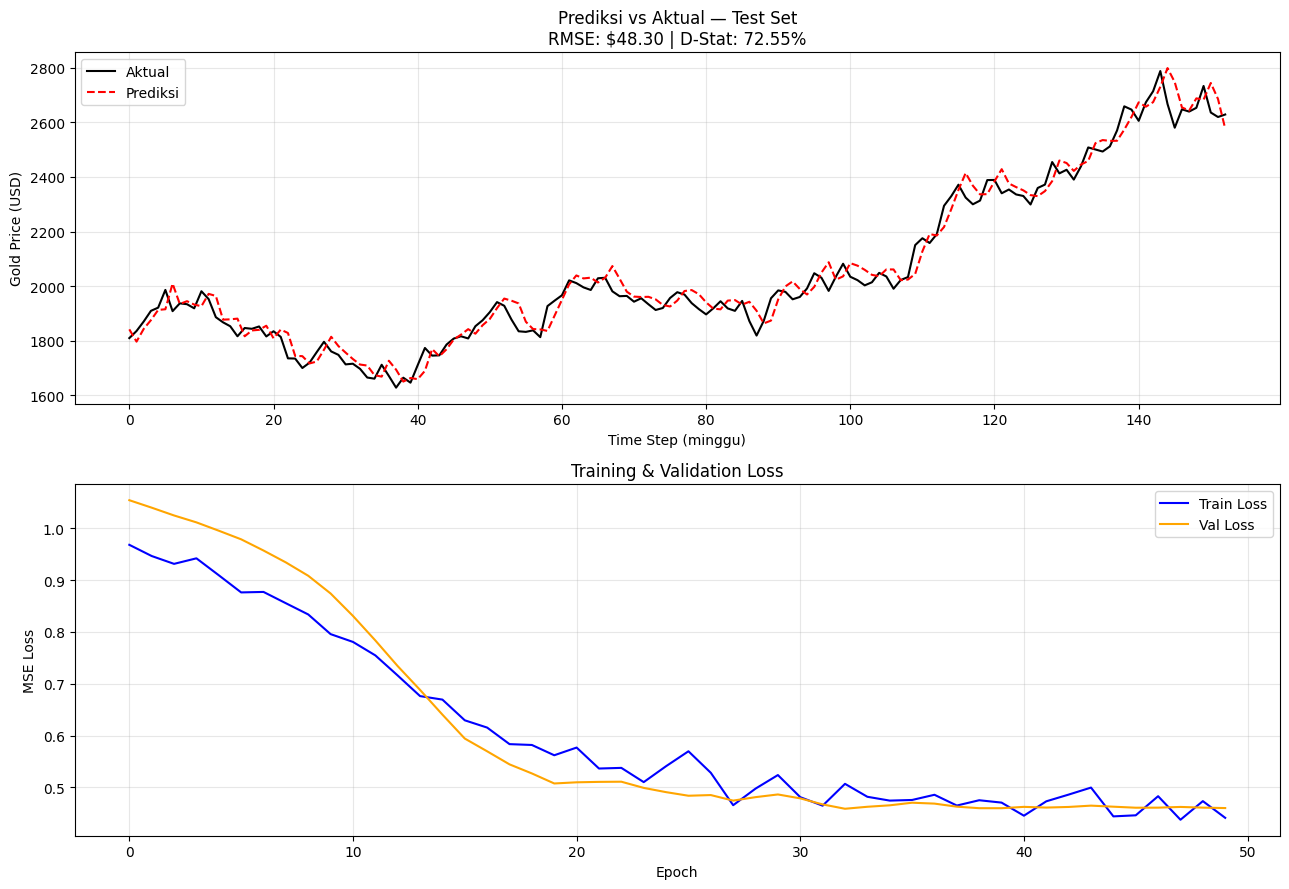

In [17]:
# 7. PLOT

fig, axes = plt.subplots(2, 1, figsize=(13, 9))

# Plot 1: Harga
axes[0].plot(y_true_price, label='Aktual', color='black', linewidth=1.5)
axes[0].plot(y_pred_price, label='Prediksi', color='red', linewidth=1.5, linestyle='--')
axes[0].set_title(f'Prediksi vs Aktual — Test Set\nRMSE: ${rmse:.2f} | D-Stat: {dstat_lag1:.2f}%')
axes[0].set_xlabel('Time Step (minggu)')
axes[0].set_ylabel('Gold Price (USD)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot 2: Training loss
axes[1].plot(history.history['loss'],     label='Train Loss', color='blue')
axes[1].plot(history.history['val_loss'], label='Val Loss',   color='orange')
axes[1].set_title('Training & Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MSE Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
# plt.savefig('lstm_gold_final_result.png', dpi=150, bbox_inches='tight')
# plt.show()
# print("Plot tersimpan.")

In [ ]:
# # ─────────────────────────────────────────────
# # 8. SIMPAN ARTIFACTS
# # ─────────────────────────────────────────────
# save_dir = '../Deploy'
# os.makedirs(save_dir, exist_ok=True)

# model.save(os.path.join(save_dir, 'lstm_gold.keras'))

# with open(os.path.join(save_dir, 'scaler_X.pkl'), 'wb') as f:
#     pickle.dump(scaler_X, f)
# with open(os.path.join(save_dir, 'scaler_y.pkl'), 'wb') as f:
#     pickle.dump(scaler_y, f)

# # Simpan last window dari test set (sudah scaled)
# last_window = X_test_s[-WINDOW_SIZE:]
# np.save(os.path.join(save_dir, 'last_window.npy'), last_window)

# # Metadata untuk deploy
# meta = {
#     'window_size'   : WINDOW_SIZE,
#     'feature_cols'  : feature_cols,  # rasio, bukan absolut
#     'target_col'    : target_col,    # y_ratio
#     'output_type'   : 'ratio',       # kalikan dengan close untuk dapat harga
#     'scaler_type'   : 'StandardScaler',
#     'last_close'    : float(df['close'].iloc[-1]),
#     'last_close_2w' : float(df['close'].iloc[-2]),
#     'last_ffr'      : float(df['ffr'].iloc[-1]),
#     'last_nfp'      : float(df['nfp'].iloc[-1]),
#     'last_date'     : str(df['date'].iloc[-1].date()),
# }
# with open(os.path.join(save_dir, 'meta.pkl'), 'wb') as f:
#     pickle.dump(meta, f)

# print(f"\nArtifacts tersimpan di: {save_dir}/")
# print(f"Files: {os.listdir(save_dir)}")